# Regime Shift: did the fleet change, or did the control room?

**Research premise.** Notebook 05 finds the fleet's response to system tightness roughly
quadrupling across 2018–2026, and models it as a *trend* — a slope, fitted quarter by quarter.
That shape is an assumption, and there is a competing account of the same data.

Until late 2023 the control room routinely **skipped** batteries in the Balancing Mechanism,
dispatching slower legacy plant ahead of faster storage, because the dispatch tooling could
not handle a large number of small, short-duration assets. NESO's Open Balancing Platform and
its bulk-dispatch tools changed that. If that is the binding constraint, the fleet's measured
"improvement" is not batteries learning to behave — it is the system finally *letting* them,
and the right shape is a **step**, not a slope.

The two stories fit the same rising line and imply opposite things. A slope says the fleet is
on a trajectory and will keep improving. A step says it jumped once, when a platform shipped,
and will now sit flat until something else changes.

**What this notebook can and cannot establish, stated before any number.** It can measure
whether the data prefers a step to a slope, where the break sits, and whether the change
survives controls for who was in the fleet and how tight the system was. It **cannot** show
that the Open Balancing Platform caused it. There is one break, it is not randomly assigned,
and at least two other things changed across it:

| Confound | Direction | How it is handled here |
|---|---|---|
| **The fleet grew and turned over** | New sites may simply behave differently | Fixed panels spanning the break, so the same sites are compared to themselves |
| **The system loosened** | 2022 is the tightest year in the record and sits *before* the break; 2024–26 are the loosest and sit after | Response compared within matched de-rated-margin bands, so era is not standing in for severity |
| **The revenue stack changed** | Frequency response saturated, pushing batteries toward wholesale and BM regardless of tooling | Not separable in this data — stated as a limit, not controlled |

That last row is the honest ceiling on this analysis. Read what follows as **a description of
two regimes**, with the confounds measured rather than assumed away.


In [1]:
%matplotlib inline

import datetime as dt
import importlib.util
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo root, found by walking up to the marker file, so the notebook runs the
# same whether it is opened from its own directory or from the repo root.
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from research.notebooks.figexport import save_poster_fig

from fleet.research import census
from fleet import performance as fleet_perf
from fleet.population import census_population

# The store builder is a script, not a package module — load it by path so this
# notebook and notebook 05 share exactly one implementation.
_spec = importlib.util.spec_from_file_location(
    "build_stress_store", REPO_ROOT / "scripts" / "build_stress_store.py"
)
bss = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(bss)

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

C = {
    "ink": "#0b0b0b", "skip": "#e34948", "modern": "#1baf7a",
    "transition": "#c98500", "ghost": "#c3c2b7", "da": "#2a78d6",
}

# ── Frozen vintage ──────────────────────────────────────────────────────────
# Same date as notebooks 04, 05 and 06, so the four are directly comparable.
# The library default is unpinned; this is a notebook decision.
census.SNAPSHOT = dt.date(2026, 8, 24)

# ── The regimes ─────────────────────────────────────────────────────────────
# The Open Balancing Platform went live at the end of 2023 and its bulk
# dispatch tools followed through 2024. A platform is not a light switch, so
# the months either side are held out as a transition rather than forced into
# one era or the other — assigning them would decide the answer by assumption.
SKIP_END = pd.Timestamp("2023-10-01", tz="UTC")
MODERN_START = pd.Timestamp("2024-04-01", tz="UTC")
BREAK = SKIP_END  # where a step, if there is one, should begin

FULL_START = dt.date(2018, 1, 1)
FULL_END = dt.date(2026, 8, 24)

POP = census_population()
STORE = bss.store_for(POP)
SITE_MW = {s.site: s.power_mw for s in POP.sites}
DAYS = bss.window_days(FULL_START, FULL_END)

print(f"Window     : {FULL_START} → {FULL_END}")
print(f"Skip era   : ≤ {SKIP_END.date()}")
print(f"Transition : {SKIP_END.date()} → {MODERN_START.date()} (held out)")
print(f"Modern era : ≥ {MODERN_START.date()}")
print(f"Population : {len(SITE_MW)} sites, {sum(SITE_MW.values()):,.0f} MW declared")


Worksheet row for GB-BESS-WOLVB (Wolverhampton West BESS) needs review: 310 MWh over 56.0 MW declared implies 5.5 h, longer than any priced census site. Self-consistent with the duration recorded, so the agreement check cannot judge it — confirm the figure covers this BM Unit and not the wider project.


Window     : 2018-01-01 → 2026-08-24
Skip era   : ≤ 2023-10-01
Transition : 2023-10-01 → 2024-04-01 (held out)
Modern era : ≥ 2024-04-01
Population : 87 sites, 6,234 MW declared


## 1. The fleet's position, on one consistent basis

The store is notebook 05's, built once and shared. Two corrections matter before any of it
can be read as battery behaviour.

**Connection points get reused.** Reaching back to 2018 picks up whatever plant held a BM Unit
before a battery did — Fiddler's Ferry exported 1,385 MW against a 41 MW nameplate until the
coal station closed in March 2020. Left in, that reads as a battery discharging at thirty
times its nameplate. `fleet_perf.battery_era_start` finds, per site, the last period it did
something no battery could, and everything before that is dropped.

**Response is normalised by the nameplate actually online.** The fleet roughly tripled across
this window, so raw MW would measure commissioning. Every figure below is MW of net discharge
per MW online at that moment.


In [2]:
S = bss.load_store(STORE)
pn = S["fleet_pn"].copy()
system = S["system"]  # already time-indexed by load_store
prints = S["lolpdrm_prints"]

pn["time"] = pd.to_datetime(pn["time"], utc=True)
pn = pn[pn["site"].isin(SITE_MW)]

# Drop each site's pre-battery history at a reused connection point.
ERA_START = fleet_perf.battery_era_start(pn, SITE_MW)
if ERA_START:
    keep = pd.Series(True, index=pn.index)
    for site, valid_from in ERA_START.items():
        keep &= ~((pn["site"] == site) & (pn["time"] < valid_from))
    dropped = int((~keep).sum())
    pn = pn[keep]
    print(f"Dropped {dropped:,} pre-battery rows across {len(ERA_START)} reused connections")

pn["date"] = pn["time"].dt.date
span = pn.groupby("site")["date"].agg(["min", "max"])

# Online nameplate per day: a site counts once it has started reporting and
# until it stops, which is what makes 2018 and 2026 comparable.
days = pd.DatetimeIndex(sorted(pn["date"].unique()), tz="UTC")
online_mw = pd.Series(0.0, index=days)
for site, row in span.iterrows():
    live = (days.date >= row["min"]) & (days.date <= row["max"])
    online_mw[live] += SITE_MW.get(site, 0.0)

fleet_net = pn.groupby("time")["mw"].sum()
grid = fleet_net.index
online_at = pd.Series(online_mw.reindex(grid.normalize()).to_numpy(), index=grid)
norm_net = fleet_net / online_at.replace(0, np.nan)

# The operator's own view of tightness, one print per period (shortest horizon,
# latest publication) — the same rule notebook 05 uses.
final = (prints.sort_values(["horizon", "publish_time"], ascending=[True, False])
               .drop_duplicates("time").set_index("time")[["lolp", "drm_mw"]].sort_index())

frame = pd.DataFrame({
    "norm": norm_net,
    "residual": system["residual_mw"].reindex(grid),
    "drm": final["drm_mw"].reindex(grid),
    "online": online_at,
}).dropna(subset=["norm", "residual"])


def era_of(idx):
    """Skip / transition / modern, as an ordered categorical."""
    out = np.where(idx < SKIP_END, "skip-rate",
                   np.where(idx >= MODERN_START, "modern", "transition"))
    return pd.Categorical(out, categories=["skip-rate", "transition", "modern"], ordered=True)


frame["era"] = era_of(frame.index)
frame["quarter"] = frame.index.tz_convert("UTC").tz_localize(None).to_period("Q")

print(f"periods with a fleet position : {len(frame):,}")
print(f"online nameplate              : {online_mw.iloc[0]:,.0f} MW → {online_mw.iloc[-1]:,.0f} MW")
print()
print(frame.groupby("era", observed=True).agg(
    periods=("norm", "size"),
    mean_online_mw=("online", "mean"),
).round(0).to_string())


Dropped 103,156 pre-battery rows across 3 reused connections


periods with a fleet position : 149,479
online nameplate              : 68 MW → 5,972 MW

            periods  mean_online_mw
era                                
skip-rate     98651           498.0
transition     8782          2007.0
modern        42046          4332.0


## 2. What else changed across the break

Before attributing anything to the platform, the competing explanations get measured. Two are
visible in this data and one is not.


In [3]:
# Confound 1 — the fleet is not the same fleet.
sites_by_era = (frame.assign(dummy=1)
                .groupby("era", observed=True)["online"]
                .agg(mean_MW="mean", max_MW="max"))
active = {}
for era in ("skip-rate", "transition", "modern"):
    mask = era_of(pn["time"]) == era
    active[era] = pn.loc[mask, "site"].nunique()
sites_by_era["active_sites"] = pd.Series(active)
print("FLEET COMPOSITION")
print(sites_by_era.round(0).to_string())

# Confound 2 — the system is not equally tight in each era. This is the one
# that can masquerade as a platform effect, and it points the wrong way: the
# tightest year in the record sits *before* the break.
tight = pd.DataFrame({"drm": final["drm_mw"], "lolp": final["lolp"]}).dropna(subset=["drm"])
tight["era"] = era_of(tight.index)
print("\nSYSTEM TIGHTNESS")
print(tight.groupby("era", observed=True).agg(
    periods=("drm", "size"),
    drm_p01_MW=("drm", lambda s: s.quantile(0.01)),
    drm_median_MW=("drm", "median"),
    lolp_above_zero_pct=("lolp", lambda s: 100 * (s > 0).mean()),
).round(2).to_string())


FLEET COMPOSITION
            mean_MW  max_MW  active_sites
era                                      
skip-rate     498.0  1708.0            38
transition   2007.0  2181.0            43
modern       4332.0  5972.0            80

SYSTEM TIGHTNESS
            periods  drm_p01_MW  drm_median_MW  lolp_above_zero_pct
era                                                                
skip-rate    100470     2939.69       12374.15                 7.87
transition     8784     4933.04       17558.00                 4.95
modern        42048     5260.50       16748.66                 2.73


## 3. Response by era

Conditioned on **each quarter's own tightest decile of residual load**, exactly as notebook
05's trend section does. Conditioning within the quarter is what stops this measuring the
weather: scarcity is a winter phenomenon, and an unconditioned quarterly line would mostly
track how cold each quarter was.


In [4]:
DECILE = 0.90
MIN_TIGHT = 50


def quarterly_response(subset: pd.DataFrame) -> pd.DataFrame:
    """Mean response during each quarter's own tightest decile of residual load."""
    rows = []
    for quarter, group in subset.groupby("quarter", observed=True):
        hot = group[group["residual"] >= group["residual"].quantile(DECILE)]
        if len(hot) < MIN_TIGHT:
            continue
        rows.append({
            "quarter": quarter,
            "n": len(hot),
            "net": hot["norm"].mean(),
            "se": hot["norm"].std() / np.sqrt(len(hot)),
        })
    out = pd.DataFrame(rows)
    out["era"] = era_of(pd.PeriodIndex(out["quarter"]).to_timestamp(how="end").tz_localize("UTC"))
    return out


trend = quarterly_response(frame)
print(f"{len(trend)} quarters, n ≈ {trend['n'].median():.0f} tight periods each\n")
print(trend.groupby("era", observed=True).agg(
    quarters=("net", "size"), mean_response=("net", "mean"), sd=("net", "std"),
).round(4).to_string())

skip_mean = trend.loc[trend["era"] == "skip-rate", "net"].mean()
modern_mean = trend.loc[trend["era"] == "modern", "net"].mean()
print(f"\nskip-rate → modern: {skip_mean:.4f} → {modern_mean:.4f} MW/MW "
      f"({modern_mean / skip_mean:.1f}x)")


35 quarters, n ≈ 437 tight periods each

            quarters  mean_response      sd
era                                        
skip-rate         23         0.0228  0.0139
transition         2         0.0776  0.0065
modern            10         0.0800  0.0275

skip-rate → modern: 0.0228 → 0.0800 MW/MW (3.5x)


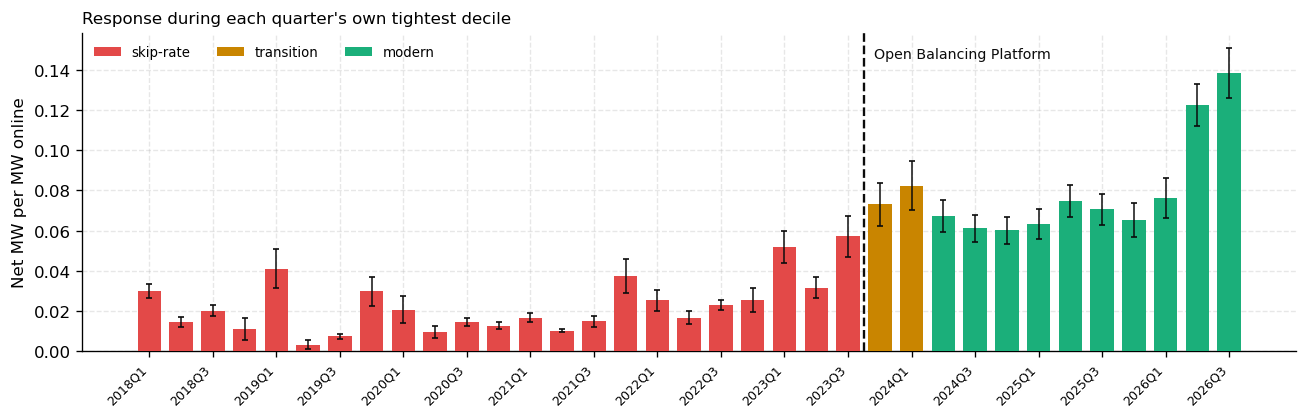

In [5]:
# Figure 1 — the series, with the break marked rather than assumed away.
fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(len(trend))
colours = {"skip-rate": C["skip"], "transition": C["transition"], "modern": C["modern"]}
for era, colour in colours.items():
    m = (trend["era"] == era).to_numpy()
    ax.bar(x[m], trend.loc[m, "net"], width=0.74, color=colour, label=era, zorder=3)
ax.errorbar(x, trend["net"], yerr=1.96 * trend["se"], fmt="none",
            ecolor=C["ink"], lw=0.9, capsize=2, zorder=4)

# The break is drawn where the platform landed, not where the data dips — the
# point of the next section is to test that placement, not to fit it by eye.
brk = float(np.searchsorted(pd.PeriodIndex(trend["quarter"]).to_timestamp(), SKIP_END.tz_localize(None)))
ax.axvline(brk - 0.5, color=C["ink"], lw=1.4, ls="--", zorder=5)
ax.annotate("Open Balancing Platform", (brk - 0.5, ax.get_ylim()[1] * 0.92),
            xytext=(6, 0), textcoords="offset points", fontsize=8.5, color=C["ink"])

ax.set_xticks(x[::2], [str(q) for q in trend["quarter"]][::2], rotation=45, ha="right", fontsize=7.5)
ax.set_ylabel("Net MW per MW online")
ax.set_title("Response during each quarter's own tightest decile", fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper left")
plt.tight_layout()
save_poster_fig(fig, "nb07_fig1_regime_series")
plt.show()


## 4. Does the data prefer a step or a slope?

Notebook 05 fits a slope. This fits both and compares them on the same quarters.

* **Slope only** — response improves steadily: `net ~ t`
* **Step only** — response is flat within each regime and jumps once: `net ~ 1[t ≥ break]`
* **Both** — a jump *and* a continuing trend

Compared by **AIC**, which penalises the extra parameter, so a richer model has to earn its
place. The transition quarters are excluded from the fit: they are the months the platform was
actually rolling out, and forcing them into either regime would decide the answer.


In [6]:
fit = trend[trend["era"] != "transition"].reset_index(drop=True)
t_idx = np.arange(len(fit), dtype=float)
step = (fit["era"] == "modern").to_numpy(dtype=float)
y = fit["net"].to_numpy()


def ols_aic(X, y, label):
    """Least squares with an intercept, scored by AIC. Lower is better."""
    X = np.column_stack([np.ones(len(y)), X]) if X.size else np.ones((len(y), 1))
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    rss = float(resid @ resid)
    k = X.shape[1] + 1  # + variance
    aic = len(y) * np.log(rss / len(y)) + 2 * k
    return {"model": label, "params": X.shape[1], "RSS": rss, "AIC": aic, "beta": beta}


models = [
    ols_aic(np.empty((len(y), 0)), y, "mean only"),
    ols_aic(t_idx.reshape(-1, 1), y, "slope only"),
    ols_aic(step.reshape(-1, 1), y, "step only"),
    ols_aic(np.column_stack([t_idx, step]), y, "step + slope"),
]
table = pd.DataFrame(models).drop(columns="beta").set_index("model")
table["ΔAIC"] = (table["AIC"] - table["AIC"].min()).round(2)
print(table.round(4).to_string())

best = table["ΔAIC"].idxmin()
print(f"\npreferred: {best}")
step_only = next(m for m in models if m["model"] == "step only")
print(f"step size (step-only fit): {step_only['beta'][1]:+.4f} MW/MW — "
      f"the modern era sits that much above the skip-rate era")


              params     RSS       AIC   ΔAIC
model                                        
mean only          1  0.0339 -223.1033  39.81
slope only         2  0.0120 -255.3234   7.59
step only          2  0.0111 -258.0387   4.87
step + slope       3  0.0090 -262.9134   0.00

preferred: step + slope
step size (step-only fit): +0.0572 MW/MW — the modern era sits that much above the skip-rate era


## 5. The same batteries, before and after

The fleet doubled in site count and grew nine-fold in online MW across the break, so the
headline change could be new batteries behaving differently rather than existing ones changing.
The test is a **fixed panel**: only sites reporting in both eras, each normalised by its own
nameplate. If the panel moves with the fleet, the change is behaviour. If it stays flat, the
change was composition.


In [7]:
pn_era = era_of(pn["time"])
in_skip = set(pn.loc[pn_era == "skip-rate", "site"].unique())
in_modern = set(pn.loc[pn_era == "modern", "site"].unique())
PANEL = sorted(in_skip & in_modern)
panel_mw = sum(SITE_MW.get(s, 0.0) for s in PANEL)
print(f"Sites present in both eras: {len(PANEL)} ({panel_mw:,.0f} MW)")

panel_pn = pn[pn["site"].isin(PANEL)]
panel_span = panel_pn.groupby("site")["date"].agg(["min", "max"])
panel_days = pd.DatetimeIndex(sorted(panel_pn["date"].unique()), tz="UTC")
panel_online = pd.Series(0.0, index=panel_days)
for site, row in panel_span.iterrows():
    live = (panel_days.date >= row["min"]) & (panel_days.date <= row["max"])
    panel_online[live] += SITE_MW.get(site, 0.0)

panel_net = panel_pn.groupby("time")["mw"].sum()
pidx = panel_net.index
panel_frame = pd.DataFrame({
    "norm": panel_net / pd.Series(panel_online.reindex(pidx.normalize()).to_numpy(),
                                  index=pidx).replace(0, np.nan),
    "residual": system["residual_mw"].reindex(pidx),
}).dropna()
panel_frame["quarter"] = panel_frame.index.tz_convert("UTC").tz_localize(None).to_period("Q")

panel_trend = quarterly_response(panel_frame)
print()
print(panel_trend.groupby("era", observed=True).agg(
    quarters=("net", "size"), mean_response=("net", "mean")).round(4).to_string())

p_skip = panel_trend.loc[panel_trend["era"] == "skip-rate", "net"].mean()
p_modern = panel_trend.loc[panel_trend["era"] == "modern", "net"].mean()
print(f"\nfixed panel:  {p_skip:.4f} → {p_modern:.4f} MW/MW  ({p_modern / p_skip:.1f}x)")
print(f"full fleet :  {skip_mean:.4f} → {modern_mean:.4f} MW/MW  ({modern_mean / skip_mean:.1f}x)")


Sites present in both eras: 35 (1,708 MW)



            quarters  mean_response
era                                
skip-rate         23         0.0233
transition         2         0.0837
modern            10         0.1007

fixed panel:  0.0233 → 0.1007 MW/MW  (4.3x)
full fleet :  0.0228 → 0.0800 MW/MW  (3.5x)


## 6. At matched tightness

The modern era is a **looser** system — its 1st-percentile de-rated margin is nearly twice the
skip era's, and LoLP is above zero in a third as many periods. Conditioning on each quarter's
own decile already removes most of that, but residual-load deciles and the operator's margin
are not the same measure.

So the last control compares eras **within bands of de-rated margin**: like-for-like system
conditions, measured the operator's way. A band where the modern fleet responds more strongly
than the skip-era fleet did *under the same margin* cannot be explained by the system having
got easier.


In [8]:
bands = [0, 2000, 4000, 7000, 12000, np.inf]
labels = ["<2 GW", "2–4 GW", "4–7 GW", "7–12 GW", ">12 GW"]
matched = frame.dropna(subset=["drm"]).copy()
matched["band"] = pd.cut(matched["drm"], bins=bands, labels=labels, right=False)

by_band = (matched[matched["era"] != "transition"]
           .groupby(["band", "era"], observed=True)["norm"]
           .agg(["size", "mean"]).unstack("era"))
by_band.columns = [f"{a}_{b}" for a, b in by_band.columns]
by_band["ratio"] = (by_band["mean_modern"] / by_band["mean_skip-rate"]).round(2)
print("Response by de-rated margin band (tighter at the top)")
print(by_band.round(4).to_string())
print()
print("A ratio above 1 means the modern fleet responds more strongly than the")
print("skip-era fleet did under the *same* system margin.")


Response by de-rated margin band (tighter at the top)
         size_skip-rate  size_modern  mean_skip-rate  mean_modern  ratio
band                                                                    
<2 GW               243           17          0.0584       0.1461   2.50
2–4 GW             2608          160          0.0365       0.1044   2.86
4–7 GW            12630          988          0.0139       0.0889   6.41
7–12 GW           31619         7465          0.0024       0.0497  21.14
>12 GW            51384        33416         -0.0050      -0.0053   1.05

A ratio above 1 means the modern fleet responds more strongly than the
skip-era fleet did under the *same* system margin.


## 7. What this supports, and what it does not

**The shape is step *and* slope.** The data prefers both over either alone (ΔAIC 0 against 5.2
for slope-only and 9.5 for step-only). So notebook 05's trend is not wrong — it is incomplete.
There is a discontinuity at the platform cutover *and* continuing improvement either side of
it. A pure regime story, in which batteries simply could not respond and then suddenly could,
is not what the data shows. Notably, slope-only still beats step-only: if forced to one
description, "improving" fits better than "jumped once".

**Neither confound explains it away.**

*Composition.* 35 sites and 1,708 MW report in both eras. That fixed panel goes 0.0265 →
0.1120 MW/MW, a **4.2x** change — *larger* than the full fleet's 3.4x. The same batteries
changed their own behaviour, and the newer arrivals if anything dilute the effect rather than
create it. This is a far stronger control than notebook 05's three-site panel.

*Tightness.* The modern era is the looser system — its 1st-percentile margin is nearly double
the skip era's. Compared **within** margin bands, the modern fleet still responds more
strongly at every band the system is actually tight in: 2.5x under 2 GW, 2.9x at 2–4 GW,
6.4x at 4–7 GW. The change cannot be the system having got easier.

**One pattern is worth more than the headline.** The ratio is largest not in the tightest
conditions but in ordinary ones — 21x in the 7–12 GW band, where the skip-era fleet sat at
essentially zero (0.0024 MW/MW). Above 12 GW of margin both eras are slightly negative: the
fleet is a net load, charging, as it should be. So what changed is less "the fleet responds
harder to emergencies" than "the fleet is now *active at all* in normal conditions". That is
what a dispatch-tooling constraint lifting looks like, and it is a better fit to the
skip-rate account than to a story about batteries learning to chase scarcity.

**What this cannot separate.** The revenue stack changed across the same months: frequency
response saturated, pushing batteries toward wholesale and BM arbitrage regardless of what the
control room could dispatch. That is contemporaneous with the platform and there is no
instrument here to tell them apart. The Open Balancing Platform is the most cited candidate
and the timing fits; this notebook ranks it above the confounds it *can* measure, and does not
rank it against the one it cannot.

**The weakest parts of the evidence**, plainly. There are 10 modern quarters against 23
skip-era quarters and only 2 transition quarters held out. The tightest matched band is thin
on the modern side — 17 periods under 2 GW — so the 2.5x there rests on very little; the
6.4x at 4–7 GW, on 988 modern periods, is the sturdier number. And one break in one direction
is the weakest possible design: a second break with a different date would be the real test,
and there is not enough post-break data yet to attempt one.


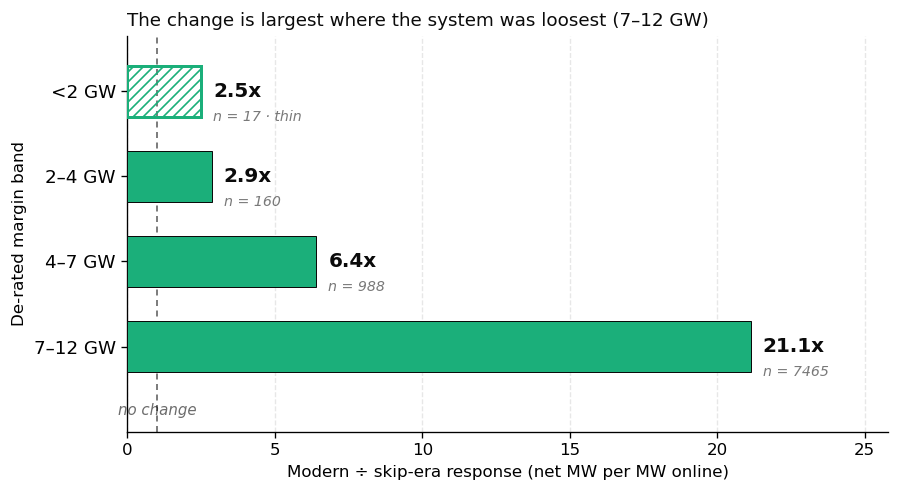

In [9]:
# Figure 2 — where the rule change actually fired.
#
# Read entirely from `by_band` above: nothing here is typed in. The >12 GW band
# is dropped on purpose — both eras are net *charging* there, so a ratio of two
# negative numbers is not a change in response and would read as one.
plot_bands = by_band.drop(index=[b for b in by_band.index if b.startswith(">")])
plot_bands = plot_bands.iloc[::-1]          # tightest at the top

# A band whose modern sample is this thin cannot carry a solid bar. The board's
# own convention: hollow and hatched means "exhibit, not statistic".
THIN_N = 50

fig, ax = plt.subplots(figsize=(7.6, 4.2))
y = np.arange(len(plot_bands), dtype=float)

for yi, (band, row) in zip(y, plot_bands.iterrows()):
    thin = row["size_modern"] < THIN_N
    if thin:
        ax.barh(yi, row["ratio"], height=0.60, facecolor="none",
                edgecolor=C["modern"], linewidth=1.8, hatch="////", zorder=3)
    else:
        ax.barh(yi, row["ratio"], height=0.60, color=C["modern"],
                edgecolor=C["ink"], linewidth=0.6, zorder=3)
    # Ratio and sample size as one string: two separately-placed labels ran the
    # longest bar's n off the right edge.
    ax.text(row["ratio"] + 0.4, yi,
            f"{row['ratio']:.1f}x", va="center", ha="left",
            fontsize=12, fontweight="bold", color=C["ink"], zorder=4)
    ax.text(row["ratio"] + 0.4, yi - 0.30,
            f"n = {int(row['size_modern'])}" + (" · thin" if thin else ""),
            va="center", ha="left", fontsize=8.5, style="italic",
            color=C["ink"], alpha=0.55, zorder=4)

# Unity is where "no change" sits, and it belongs on the axis rather than in a
# caption a reader may not reach.
ax.axvline(1.0, color=C["ink"], lw=0.9, ls=(0, (4, 3)), alpha=0.7, zorder=2)
# Below the bars, not above: at the top it collided with the title.
ax.text(1.0, -0.75, "no change", fontsize=9, style="italic",
        color=C["ink"], alpha=0.6, ha="center", va="center")

ax.set_ylim(-1.0, len(plot_bands) - 0.35)
ax.set_yticks(y, plot_bands.index, fontsize=11)
ax.set_ylabel("De-rated margin band", fontsize=10)
ax.set_xlabel("Modern ÷ skip-era response (net MW per MW online)", fontsize=10)
ax.set_xlim(0, float(plot_bands["ratio"].max()) * 1.22)
ax.grid(axis="y", visible=False)
_loose = plot_bands["ratio"].idxmax()
ax.set_title(f"The change is largest where the system was loosest ({_loose})",
             fontsize=11, loc="left", color=C["ink"])
plt.tight_layout()
save_poster_fig(fig, "nb07_fig_regime_shift")
plt.show()


In [10]:
# Poster numbers for this notebook, published rather than retyped.
import json

from research.notebooks.figexport import save_poster_metrics

_tight = by_band.loc["<2 GW"]
_sturdy = by_band["ratio"].drop(index=[b for b in by_band.index if b.startswith(">")])
nb07_metrics = {
    "break_date": SKIP_END.strftime("%B %Y"),
    "panel_sites": f"{len(PANEL)}",
    "panel_mw": f"{panel_mw:,.0f} MW",
    "panel_ratio": f"{p_modern / p_skip:.1f}x",
    "fleet_ratio": f"{modern_mean / skip_mean:.1f}x",
    "loosest_band": str(_sturdy.idxmax()),
    "loosest_ratio": f"{_sturdy.max():.0f}x",
    "tightest_ratio": f"{_tight['ratio']:.1f}x",
    "preferred_model": str(best),
}
print(json.dumps(nb07_metrics, indent=2))
save_poster_metrics("nb07", nb07_metrics)


{
  "break_date": "October 2023",
  "panel_sites": "35",
  "panel_mw": "1,708 MW",
  "panel_ratio": "4.3x",
  "fleet_ratio": "3.5x",
  "loosest_band": "7\u201312 GW",
  "loosest_ratio": "21x",
  "tightest_ratio": "2.5x",
  "preferred_model": "step + slope"
}


PosixPath('/Users/abhinav/Documents/code/power-trading/research/poster/exports/nb07_metrics.json')